# Comparing latent distributions across architectures and attacks

Notebook 01 looked at one backdoored model. This one asks what generalizes.

Two questions run through it:

1. **Does the backdoor appear at the same relative depth on ViT and Swin?**
   ViT-B/16 has 12 blocks and Swin-S has 24, so depth is plotted as a fraction of
   the stack rather than as a block index.
2. **Which statistic actually distinguishes a backdoored model from a benign one?**
   A trigger changes the pixels, so a benign model separates triggered from clean
   images too. Any statistic that cannot tell those apart is measuring the trigger
   rather than the backdoor.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from psbd.analysis.cases import case_distribution_table, load_latent_case

SAMPLES = 1000

# A benign model has no trigger of its own, so it is probed with a named one.
# Chance-level behaviour is the expected result and the control for everything else.
CASES = [
    ("vit_cifar100_badnet_a2o_0_01", None),
    ("vit_cifar100_blend_0_01", None),
    ("vit_cifar100_wanet_0_01", None),
    ("vit_cifar100_sig_0_01", None),
    ("vit_cifar100_benign", "badnet_a2o"),
    ("swin_cifar100_badnet_a2o_0_01", None),
    ("swin_cifar100_blend_0_01", None),
    ("swin_cifar100_benign", "badnet_a2o"),
]
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

device: cuda


## Build every table

Only the per-layer tables are kept. The features themselves are large and are
released as soon as a table has been computed from them, so the whole grid fits in
memory regardless of how many cases are added.

In [2]:
rows = []
for folder, probe in CASES:
    case = load_latent_case(folder, samples=SAMPLES, probe_attack=probe)
    table = case_distribution_table(case)
    depth = max(row["layer"] for row in table)
    for row in table:
        rows.append(
            {
                "case": folder,
                "architecture": case.architecture,
                "attack": case.attack if probe is None else "benign control",
                "relative_depth": row["layer"] / depth,
                **row,
            }
        )
    print(f"{folder:34s}  {case.architecture:5s}  {depth} blocks")
    del case

frame = pd.DataFrame(rows)
frame.shape

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


vit_cifar100_badnet_a2o_0_01        vit    12 blocks


/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


vit_cifar100_blend_0_01             vit    12 blocks


/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


...

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


swin_cifar100_blend_0_01            swin   24 blocks


/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


swin_cifar100_benign                swin   24 blocks


(140, 14)

## Where the backdoor becomes separable

Read the benign control against the rest. If a backdoored curve is not clearly
above its architecture's control, the statistic is not detecting the backdoor.

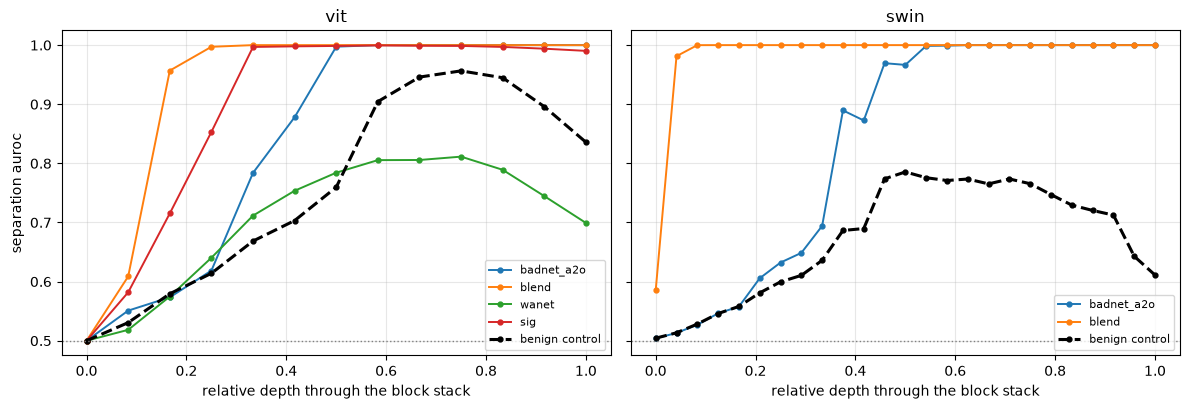

In [3]:
def plot_metric(metric, ylabel, reference=None):
    architectures = list(dict.fromkeys(frame["architecture"]))
    figure, axes = plt.subplots(
        1, len(architectures), figsize=(6 * len(architectures), 4.2), sharey=True
    )
    for axis, architecture in zip(axes, architectures):
        subset = frame[frame["architecture"] == architecture]
        for case, group in subset.groupby("case", sort=False):
            control = group["attack"].iloc[0] == "benign control"
            axis.plot(
                group["relative_depth"],
                group[metric],
                marker="o",
                markersize=3.5,
                lw=2.2 if control else 1.4,
                ls="--" if control else "-",
                c="black" if control else None,
                label=group["attack"].iloc[0],
            )
        if reference is not None:
            axis.axhline(reference, ls=":", lw=1, c="grey")
        axis.set_title(architecture)
        axis.set_xlabel("relative depth through the block stack")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)
    axes[0].set_ylabel(ylabel)
    figure.tight_layout()
    return figure


plot_metric("separation_auroc", "separation auroc", reference=0.5)
plt.show()

Separation alone does not identify a backdoor. The benign control climbs too,
because a triggered image really is a different image.

## What the backdoor changes and the trigger alone does not

CKA asks how much of the whole representation survives the trigger. A benign model
should stay near 1, since the trigger perturbs its features without reorganizing
them.

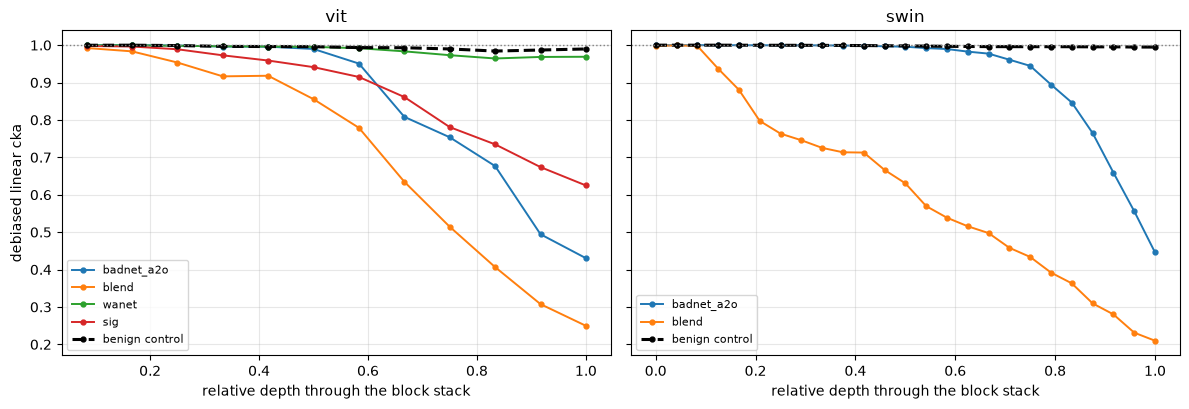

In [4]:
plot_metric("cka", "debiased linear cka", reference=1.0)
plt.show()

`rank_ratio` is the number of directions the backdoor population occupies divided
by the number the clean population occupies. Below 1 means the trigger is
compressing the representation onto a smaller subspace.

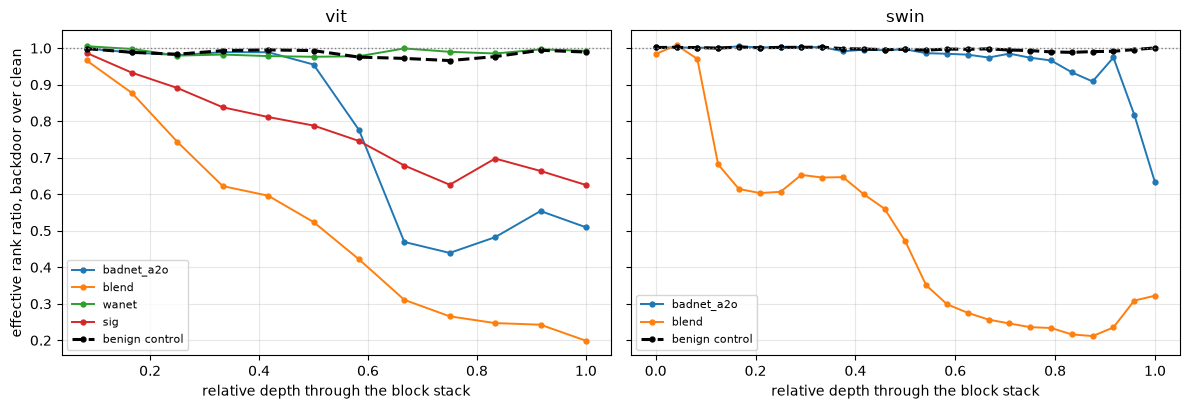

In [5]:
plot_metric("rank_ratio", "effective rank ratio, backdoor over clean", reference=1.0)
plt.show()

## Summary per case

`first_separable` is the shallowest relative depth reaching 0.9 separation auroc.
`min_cka` and `min_rank_ratio` are the deepest points of the two collapse
measures, and `max_target_alignment` is how far the trigger's direction ever
points at the target class.

In [6]:
def summarize(group):
    separable = group[group["separation_auroc"] > 0.9]["relative_depth"]
    return pd.Series(
        {
            "architecture": group["architecture"].iloc[0],
            "attack": group["attack"].iloc[0],
            "first_separable": separable.min() if len(separable) else float("nan"),
            "final_auroc": group["separation_auroc"].iloc[-1],
            "min_cka": group["cka"].min(),
            "min_rank_ratio": group["rank_ratio"].min(),
            "max_target_alignment": group["target_alignment"].max(),
        }
    )


summary = frame.groupby("case", sort=False).apply(summarize, include_groups=False)
summary.round(3)

,architecture,attack,first_separable,final_auroc,min_cka,min_rank_ratio,max_target_alignment
case,,,,,,,
vit_cifar100_badnet_a2o_0_01,vit,badnet_a2o,0.500,1.000,0.430,0.439,0.658
vit_cifar100_blend_0_01,vit,blend,0.167,1.000,0.250,0.199,0.788
vit_cifar100_wanet_0_01,vit,wanet,NaN,0.699,0.964,0.976,0.670
vit_cifar100_sig_0_01,vit,sig,0.333,0.990,0.625,0.625,0.161
vit_cifar100_benign,vit,benign control,0.583,0.836,0.984,0.966,0.174
swin_cifar100_badnet_a2o_0_01,swin,badnet_a2o,0.458,1.000,0.446,0.632,0.725
swin_cifar100_blend_0_01,swin,blend,0.042,1.000,0.210,0.212,0.694
swin_cifar100_benign,swin,benign control,NaN,0.611,0.995,0.988,0.120


## Reading the comparison

The control column is the one that matters. A statistic is only evidence of a
backdoor if the backdoored models separate from the benign model probed with the
same trigger, and separation auroc largely does not: a trigger is a visible input
perturbation on any model.

The collapse measures behave differently. A benign model's representation is
perturbed by the trigger but keeps its shape, so its CKA stays high and its rank
ratio stays near 1. A backdoored model reorganizes, and both fall.

**With one exception, and it is the informative one.** WaNet at 1 percent sits with
the benign controls on both collapse columns rather than with the backdoored
models. That is not a failure of the measure. WaNet is independently known not to
implant at 1 percent on any dataset in this project, so a checkpoint carrying its
trigger but not its backdoor is exactly what the controls should look like. The
measure is reporting that no backdoor was learned, which is correct, and it is
doing so from the latent geometry alone without being told the attack succeeded.

Read the WaNet row as the second negative control rather than as a miss. It also
sets the honest limit on the claim: these columns track whether a backdoor was
**learned**, not whether a trigger was **applied**, and a reader who wants a
trigger detector rather than a backdoor detector needs a different statistic.